In [376]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import *
from random import seed
from scipy import stats
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
import statsmodels.api as sm
from statsmodels.stats.api import anova_lm
from statsmodels.formula.api import ols
from statsmodels.regression import linear_model
from sklearn.metrics import explained_variance_score
from statsmodels.stats.mediation import Mediation
from sklearn.linear_model import LassoCV, RidgeCV, Lasso
from pingouin import ancova
import matplotlib.cm as cm
from scipy.stats.stats import pearsonr


%matplotlib inline

seed(888)
pd.set_option('display.max_columns', None)

/tmp/ipykernel_760239/3379509306.py:18: DeprecationWarning: Please use `pearsonr` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  from scipy.stats.stats import pearsonr


# 1 Load data from "2 BrainAge"

In [377]:
# load data from pickle and convert to dataframe
main_test = pd.read_pickle("2_main_test.pkl")
main_train = pd.read_pickle("2_main_train.pkl")
main_test = pd.DataFrame(main_test)
main_train = pd.DataFrame(main_train)

In [378]:
edu = main_test[main_test["EDUL"]=="Prefer not to answer"].index
main_test = main_test.drop(edu)
print(edu)

Int64Index([  842,  4607,  6841,  7321, 11768, 13776, 17616, 18380, 26831,
            29780, 32069, 33693, 34924, 38820, 40126],
           dtype='int64')


# 2 Preprocessing and descriptives

## 2.1 Data

In [379]:
main_test.head()

,ID,Age,Gender,IS,TPA,VPA,MPA,MVPA,LPA,SRLPA,SRMPA,SRVPA,HG,HR,BMI,DBP,SBP,EDUA,EDUL,BADA2009,BADASEG,BADDesikan,BADCombined
10,1001365,71.0,Female,11025,3396.9600,20.1600,514.0800,554.4000,2862.7200,594.0,240.0,240.0,20.0,73.0,28.2030,70.0,106.0,16.0,O levels/GCSEs or equivalent,-3.272061,-5.762153,-0.972775,-4.348802
17,1001748,48.0,Female,11025,3126.8160,265.3056,596.9376,1127.5488,2264.5728,462.0,0.0,2400.0,34.0,52.0,25.7857,75.0,124.0,18.0,O levels/GCSEs or equivalent,4.175501,-2.619043,5.079592,-0.122651
20,1001984,69.0,Female,11026,2468.4192,9.9936,579.6288,599.6160,1878.7968,693.0,960.0,0.0,26.0,76.0,25.7422,79.0,120.0,16.0,O levels/GCSEs or equivalent,1.744594,-3.907803,-7.487591,-0.339589
21,1002138,56.0,Female,11025,2465.2224,29.1168,427.0464,485.2800,2009.0592,2970.0,720.0,240.0,18.0,56.0,33.5680,75.0,134.0,20.0,O levels/GCSEs or equivalent,-4.797479,-11.749959,1.942913,-4.609280
23,1002288,63.0,Female,11025,2559.7728,109.1376,704.4336,922.7088,1746.2016,264.0,960.0,0.0,30.0,85.0,27.4762,84.0,146.0,NaN,College or University degree,-5.003056,-4.366149,-4.328995,-3.523589


## 2.2 Remove outliers on SR PA

In [380]:
# remove outliers on self-reported physical activity data for each intensity seperately
before = main_test.shape[0]
outlier = np.mean(main_test["SRLPA"]) + np.std(main_test["SRLPA"])*3
main_test = main_test[main_test["SRLPA"]<outlier]
outlier = np.mean(main_test["SRMPA"]) + np.std(main_test["SRMPA"])*3
main_test = main_test[main_test["SRMPA"]<outlier]
outlier = np.mean(main_test["SRVPA"]) + np.std(main_test["SRVPA"])*3
main_test = main_test[main_test["SRVPA"]<outlier]
after = main_test.shape[0]
print("Outliers on self-reported PA:", before-after)
print(after)

Outliers on self-reported PA: 560
5410


## 2.3 Convert SRPA from MET min/week to min/week

In [381]:
main_test["SRLPA"] = main_test["SRLPA"]/3.3
main_test["SRMPA"] = main_test["SRMPA"]/4
main_test["SRVPA"] = main_test["SRVPA"]/8

main_train["SRLPA"] = main_train["SRLPA"]/3.3
main_train["SRMPA"] = main_train["SRMPA"]/4
main_train["SRVPA"] = main_train["SRVPA"]/8

## 2.4 Remove people with Gender other than Male or Female

In [382]:
before = main_test.shape[0]
main_test = main_test[(main_test["Gender"] == "Female") | (main_test["Gender"] == "Male")]
after = main_test.shape[0]
print("Gender not Male or Female:", before-after)
print(after)

Gender not Male or Female: 0
5410


## 2.5 Test set descriptives

In [383]:
# get mean and std for all variables for males and females seperately for the test set
female = main_test[main_test["Gender"] == "Female"]
male = main_test[main_test["Gender"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = main_test["Age"].mean()
print("Mean", mean)
std = main_test["Age"].std()
print("Std",std)

print("LPA")
mean = main_test["LPA"].mean()
print("Mean", mean)
std = main_test["LPA"].std()
print("Std",std)

print("MPA")
mean = main_test["MPA"].mean()
print("Mean", mean)
std = main_test["MPA"].std()
print("Std",std)

print("VPA")
mean = main_test["VPA"].mean()
print("Mean", mean)
std = main_test["VPA"].std()
print("Std",std)

print("SRLPA")
mean = main_test["SRLPA"].mean()
print("Mean", mean)
std = main_test["SRLPA"].std()
print("Std",std)

print("SRMPA")
mean = main_test["SRMPA"].mean()
print("Mean", mean)
std = main_test["SRMPA"].std()
print("Std",std)

print("SRVPA")
mean = main_test["SRVPA"].mean()
print("Mean", mean)
std = main_test["SRVPA"].std()
print("Std",std)

print("DBP")
mean = main_test["DBP"].mean()
print("Mean", mean)
std = main_test["DBP"].std()
print("Std",std)

print("SBP")
mean = main_test["SBP"].mean()
print("Mean", mean)
std = main_test["SBP"].std()
print("Std",std)

print("BMI")
mean = main_test["BMI"].mean()
print("Mean", mean)
std = main_test["BMI"].std()
print("Std",std)

print("HG")
mean = main_test["HG"].mean()
print("Mean", mean)
std = main_test["HG"].std()
print("Std",std)

print("HR")
mean = main_test["HR"].mean()
print("Mean", mean)
std = main_test["HR"].std()
print("Std",std)

print("IS")
print(main_test["IS"].value_counts())

print("EDUA")
print(main_test["EDUA"].value_counts())

print("EDUL")
print(main_test["EDUL"].value_counts())

Number of females: 2893
NUmber of males: 2517
Age
Mean 64.4166358595194
Std 7.743423223084423
LPA
Mean 1976.9216845841036
Std 414.8292137777303
MPA
Mean 484.4173548243994
Std 223.4087277242472
VPA
Mean 33.87367896487988
Std 44.57648961925181
SRLPA
Mean 233.96783733826248
Std 216.21816560690934
SRMPA
Mean 158.59907578558224
Std 191.4536434159878
SRVPA
Mean 64.17744916820702
Std 82.65668678330978
DBP
Mean 81.12421441774492
Std 10.413972722407959
SBP
Mean 136.5894639556377
Std 18.799893004289288
BMI
Mean 26.334092033271716
Std 4.2281519593890495
HG
Mean 33.6090573012939
Std 10.95014801623315
HR
Mean 67.98040665434381
Std 10.696072914887235
IS
11025    3322
11027    1150
11026     933
11028       5
Name: IS, dtype: int64
EDUA
 16.0    817
 18.0    455
 15.0    450
 17.0    342
 21.0    139
 19.0    112
 20.0     91
 22.0     55
 23.0     30
 24.0     18
 14.0     15
 25.0      8
-1.0       7
 27.0      7
 5.0       5
 30.0      3
 35.0      2
-3.0       2
 28.0      2
 11.0      1
 33.0   

## 2.6 Train set descriptives

In [384]:
# get mean and std for all variables for males and females seperately for the test set
female = main_train[main_train["Gender"] == "Female"]
male = main_train[main_train["Gender"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = main_train["Age"].mean()
print("Mean", mean)
std = main_train["Age"].std()
print("Std",std)

print("SRLPA")
mean = main_train["SRLPA"].mean()
print("Mean", mean)
std = main_train["SRLPA"].std()
print("Std",std)

print("SRMPA")
mean = main_train["SRMPA"].mean()
print("Mean", mean)
std = main_train["SRMPA"].std()
print("Std",std)

print("SRVPA")
mean = main_train["SRVPA"].mean()
print("Mean", mean)
std = main_train["SRVPA"].std()
print("Std",std)

print("DBP")
mean = main_train["DBP"].mean()
print("Mean", mean)
std = main_train["DBP"].std()
print("Std",std)

print("SBP")
mean = main_train["SBP"].mean()
print("Mean", mean)
std = main_train["SBP"].std()
print("Std",std)

print("BMI")
mean = main_train["BMI"].mean()
print("Mean", mean)
std = main_train["BMI"].std()
print("Std",std)

print("HG")
mean = main_train["HG"].mean()
print("Mean", mean)
std = main_train["HG"].std()
print("Std",std)

print("HR")
mean = main_train["HR"].mean()
print("Mean", mean)
std = main_train["HR"].std()
print("Std",std)

print("IS")
print(main_train["IS"].value_counts())

print("EDUA")
print(main_train["EDUA"].value_counts())

print("EDUL")
print(main_train["EDUL"].value_counts())

Number of females: 11117
NUmber of males: 10325
Age
Mean 64.39889002891522
Std 7.649732872523935
SRLPA
Mean 289.784948011223
Std 309.29411344455514
SRMPA
Mean 206.94867139792044
Std 280.6411674181547
SRVPA
Mean 82.22308411729108
Std 130.49491812800625
DBP
Mean 81.29120713856025
Std 10.363904029343296
SBP
Mean 136.45067174654102
Std 18.67013239738352
BMI
Mean 26.645524985989166
Std 4.237943939447412
HG
Mean 33.90108039848464
Std 11.262323642066619
HR
Mean 68.077150591538
Std 10.972897755270589
IS
11025    12729
11027     5651
11026     3034
11028       28
Name: IS, dtype: int64
EDUA
 16.0    3996
 15.0    2165
 18.0    1779
 17.0    1479
 21.0     662
 19.0     442
 20.0     312
 22.0     236
 23.0     122
 14.0      76
 24.0      69
 25.0      55
-1.0       37
-3.0       32
 26.0      26
 27.0      15
 35.0      14
 28.0      12
 30.0      12
 32.0      10
 31.0       9
 29.0       6
 34.0       6
 33.0       5
 5.0        3
 13.0       2
 12.0       1
-2.0        1
 10.0       1
 11.0

## 2.7 Age and BrainAge

In [385]:
# # plot Age by Gender
# plt.figure()
# sns.kdeplot(data = main_test, x= 'Age', hue = 'Gender', fill=True, palette = "crest")
# plt.title("Age x Gender")
# plt.show()

# # plot BrainAGE by Gender
# plt.figure()
# sns.kdeplot(data = main_test, x= 'BADA2009', hue = 'Gender', fill=True, palette = "crest")
# plt.title("BrainAge x Gender")
# plt.show()

# # plot BrainAGE by Imaging Site
# plt.figure()
# sns.kdeplot(data = main_test, x= 'BADA2009', hue = 'IS', fill=True, palette = "crest")
# plt.title("BrainAge x Imaging site")
# plt.show()

# # plot Age by Imaging Site
# plt.figure()
# sns.kdeplot(data = main_test, x= 'Age', hue = 'IS', fill=True, palette = "crest")
# plt.title("Age x Imaging site")
# plt.show()

# # plot Moderate PA by Imaging Site
# plt.figure()
# sns.kdeplot(data = main_test, x= 'MPA', hue = 'IS', fill=True, palette = "crest")
# plt.title("Moderate PA x Imaging site")
# plt.show()

# # plot BrainAGE Segmentations
# plt.figure()
# sns.kdeplot(data = main_test, x= 'BADA2009', fill=True, label="Destrieux")
# sns.kdeplot(data = main_test, x= 'BADASEG', fill=True, label="ASEG")
# sns.kdeplot(data = main_test, x= 'BADDesikan', fill=True, label="Desikan")
# plt.xlabel("BrainAGE", fontsize=14)
# plt.ylabel("Density", fontsize=14)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.legend(fontsize=14)
# plt.show()

## 2.8 Physical activity

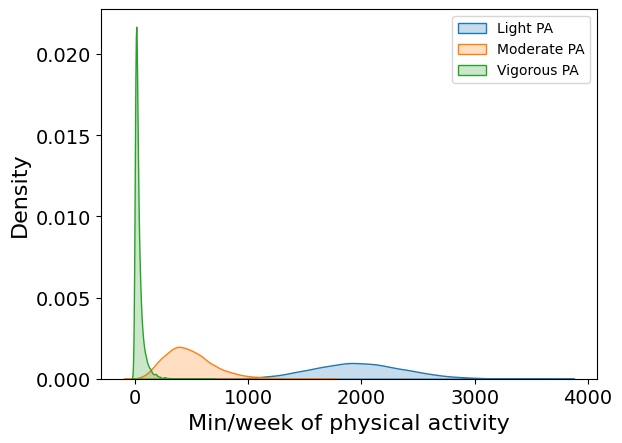

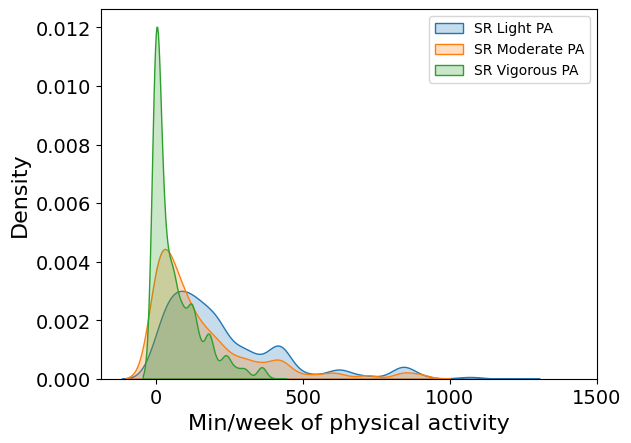

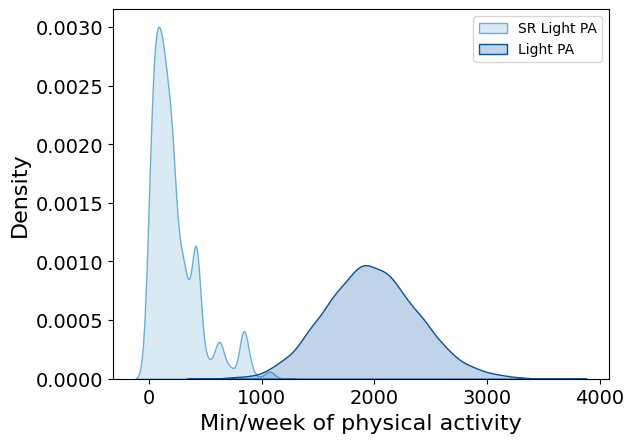

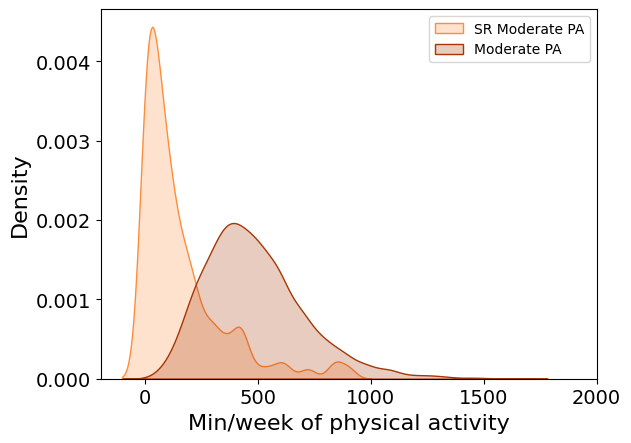

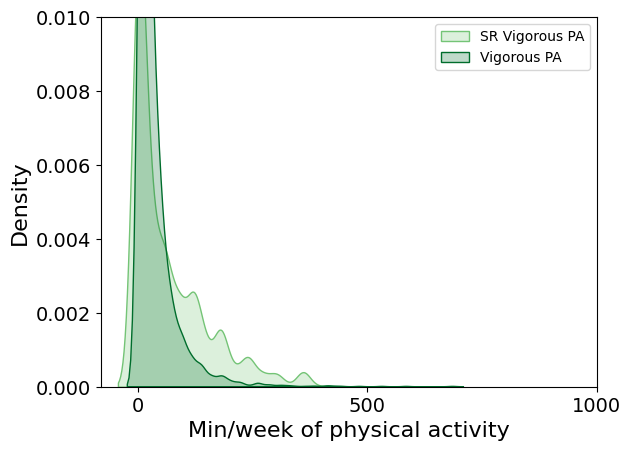

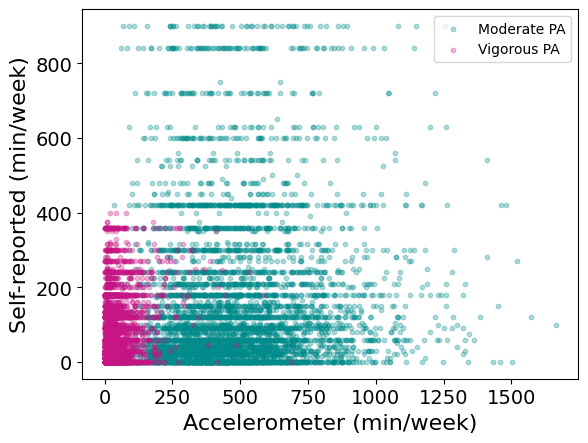

In [386]:
# plot physical activity intensity categories for self-report and accelerometer together and seperately

plt.figure()
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,5000,1000),fontsize = 14)
#plt.ylim(0,0.01)
plt.ylabel("Density",fontsize = 16)
plt.yticks(fontsize = 14)
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA")
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA")
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,2000,500),fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA", color="#6baed6")
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA", color="#08519c")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,4500,1000),fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA", color="#fd8d3c")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA", color="#a63603")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,2500,500),fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA", color="#74c476")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA", color="#006d2c")
plt.ylim(0,0.01)
plt.xticks(range(0,1500,500),fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.legend()
plt.show()

plt.figure()
plt.scatter("MPA", "SRMPA", data = main_test, label = "Moderate PA", alpha=0.3, s=10, color = "darkcyan")
plt.scatter("VPA", "SRVPA", data = main_test, label = "Vigorous PA", alpha=0.3, s=10, color = "mediumvioletred")
plt.ylabel("Self-reported (min/week)", fontsize = 16)
plt.xlabel("Accelerometer (min/week)", fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc="best")
plt.show()

## 2.9 Fitness

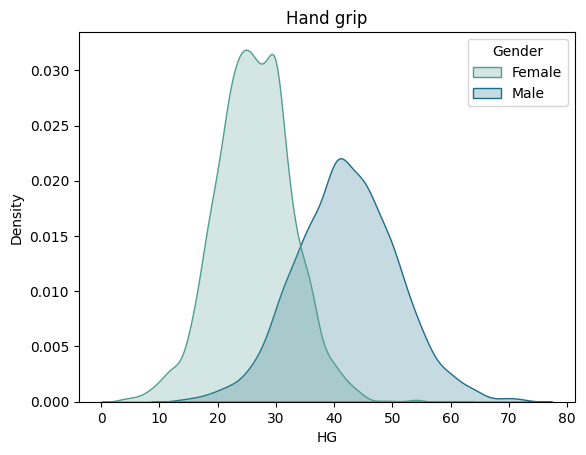

In [387]:
# plot dominant hand grip strength
plt.figure()
sns.kdeplot(data = main_test, x= 'HG', hue = 'Gender', fill=True, palette = "crest")
plt.title("Hand grip")
plt.show()

## 2.10 Health

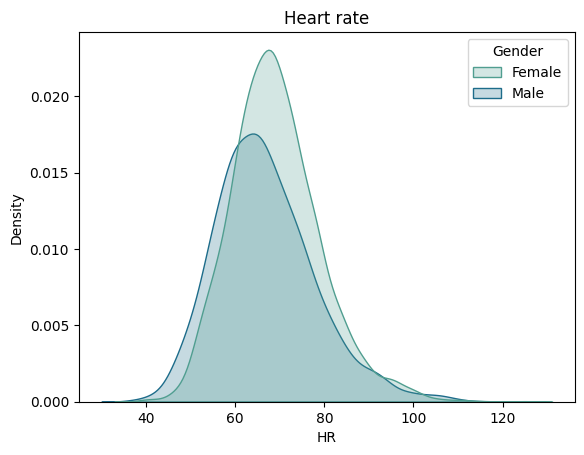

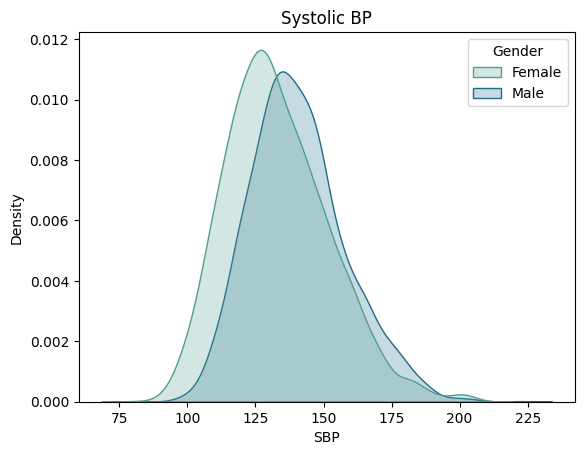

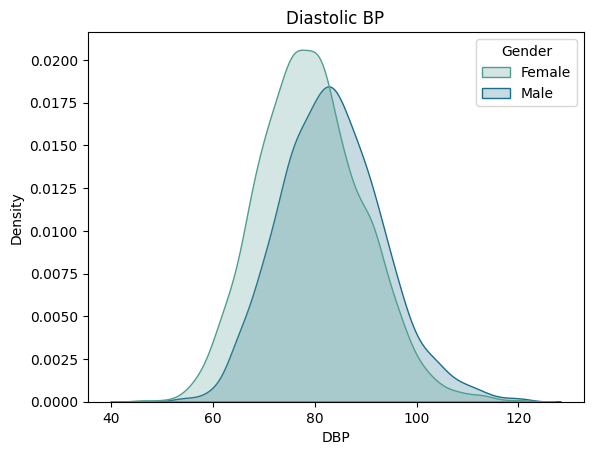

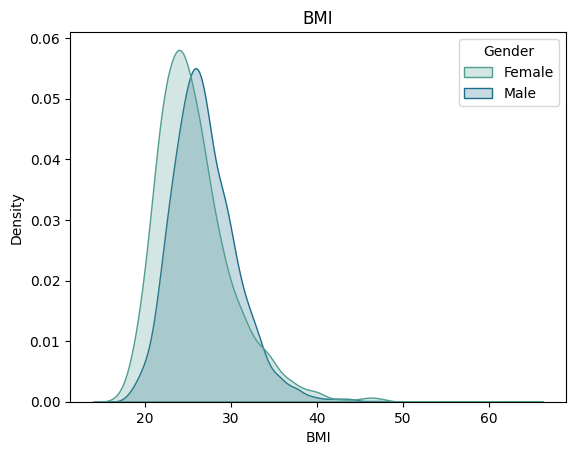

In [388]:
# plot Heart rate
plt.figure()
sns.kdeplot(data = main_test, x= 'HR', hue = 'Gender', fill=True, palette = "crest")
plt.title("Heart rate")
plt.show()

# plot systolic blood pressure
plt.figure()
sns.kdeplot(data = main_test, x= 'SBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Systolic BP")
plt.show()

# plot diastolic blood pressure
plt.figure()
sns.kdeplot(data = main_test, x= 'DBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Diastolic BP")
plt.show()

# plot BMI
plt.figure()
sns.kdeplot(data = main_test, x= 'BMI', hue = 'Gender', fill=True, palette = "crest")
plt.title("BMI")
plt.show()

# 3 Recode variables

In [389]:
# recode Imaging site and Gender
# 1 = Cheadle;  2 = Reading;  3 = Newcastle;  4 = Bristol
main_test['IS'] = main_test['IS'].map({'11025': 0, '11026': 1,'11027': 2, '11028': 3})
# fix this
main_test['EDUL'] = main_test['EDUL'].map({'None of the above': 0, 'Other professional qualifications eg: nursing, teaching': 5,'NVQ or HND or HNC or equivalent': 4, 'CSEs or equivalent': 1, 'O levels/GCSEs or equivalent':2, 'A levels/AS levels or equivalent':3,'College or University degree':6})
main_test["Gender"] = main_test["Gender"].map({"Female":0, "Male":1})
main_test["Gender"] = main_test["Gender"].astype("int")
main_test = main_test.rename(columns={"BADCombined": "BA"})

print("EDU")
print(main_test["EDUL"].value_counts())

EDU
6.0    2833
2.0     975
3.0     713
4.0     248
0.0     244
5.0     228
1.0     169
Name: EDUL, dtype: int64


# 4 Reorder dataframe and delete unused variables

In [390]:
main_test = main_test[['Age', 'Gender', 'IS' , 'LPA', 'MPA', 'VPA', 'SRLPA', 'SRMPA', 'SRVPA', 'HG', 'HR', 'BMI', 'DBP', 'SBP', "EDUL", "EDUA", 'BA']]

# 5 Correlation heatmap

In [391]:
def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
    return pvalues

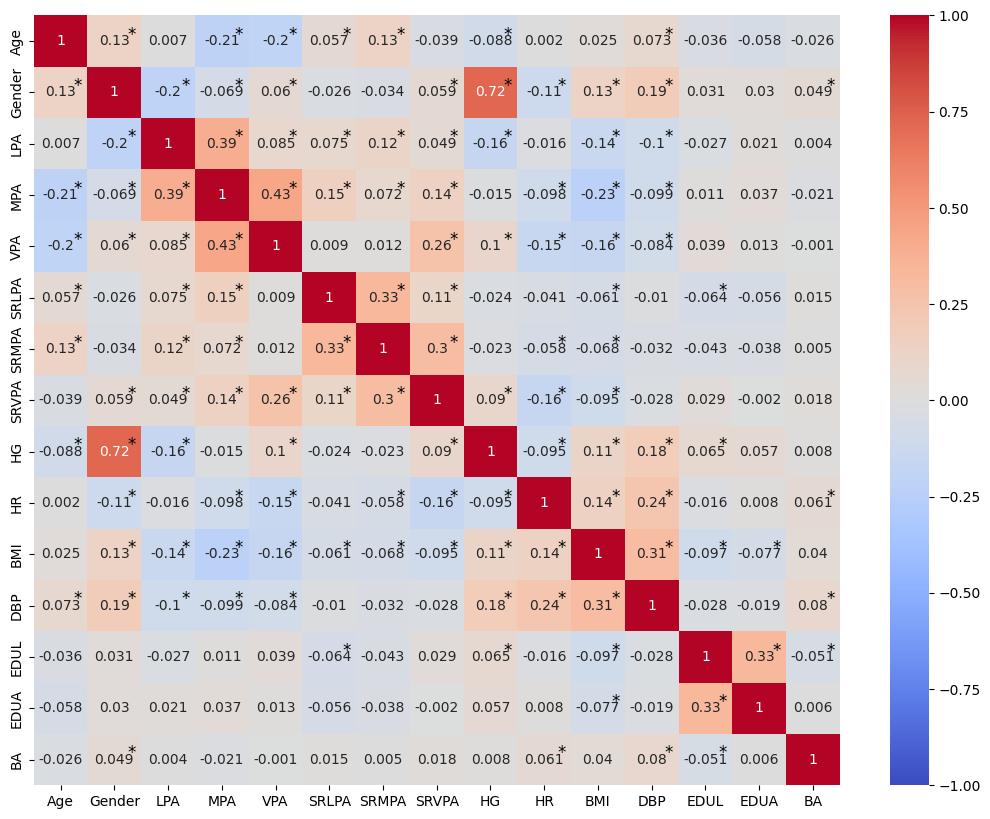

In [392]:
corr_test = main_test
corr_test = corr_test[:]
#del corr_test["BA"]
del corr_test["SBP"]
del corr_test["IS"]
#del corr_test["EDU"]
corr = corr_test.corr()
corr = round(corr,3)

fig, ax = plt.subplots(figsize=(13,10)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)


p_values = np.asarray(calculate_pvalues(corr_test))

threshold = 0.0007575  # Define your significance threshold

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if i != j:
            correlation = corr.iloc[i, j]
            p_value = p_values[i,j]  # Calculate or provide the p-value for the correlation

            if p_value < threshold:
                ax.text(j + 0.9, i + 0.2, "*", ha='right', va='top', color='black', fontsize=12)

# 6 Models OLS

## 6.1 PA BrainAGE Regression

### 6.1.1 Baseline Covariates

In [393]:
cov_model = ols('BA ~ Gender + Age + IS + EDUL', missing='drop', data = main_test).fit()
print(cov_model.summary())

#calculate effect size
results = cov_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     9.803
Date:                Sat, 23 Nov 2024   Prob (F-statistic):           6.72e-08
Time:                        15:17:06   Log-Likelihood:                -17153.
No. Observations:                5410   AIC:                         3.432e+04
Df Residuals:                    5405   BIC:                         3.435e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.0399      0.686      2.974      0.0

### 6.1.2 Accelerometer PA

In [394]:
lpa = ols('BA ~ LPA + Age + Gender + IS + EDUL + Gender:LPA + EDUL:LPA', missing='drop', data = main_test).fit()
print(lpa.summary())

#calculate effect size
results = lpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     5.934
Date:                Sat, 23 Nov 2024   Prob (F-statistic):           6.78e-07
Time:                        15:17:06   Log-Likelihood:                -17152.
No. Observations:                5410   AIC:                         3.432e+04
Df Residuals:                    5402   BIC:                         3.437e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7844      1.207      0.650      0.5

In [395]:
mpa = ols('BA ~ MPA + Age + Gender + IS + EDUL + Gender:MPA + EDUL:MPA', missing='drop', data = main_test).fit()
print(mpa.summary())

#calculate effect size
results = mpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     8.021
Date:                Sat, 23 Nov 2024   Prob (F-statistic):           9.95e-10
Time:                        15:17:06   Log-Likelihood:                -17145.
No. Observations:                5410   AIC:                         3.431e+04
Df Residuals:                    5402   BIC:                         3.436e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.6150      0.845      1.912      0.0

In [396]:
vpa = ols('BA ~ VPA + Age + Gender + IS + EDUL + Gender:VPA + EDUL:VPA', missing='drop', data = main_test).fit()
print(vpa.summary())

#calculate effect size
results = vpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     6.570
Date:                Sat, 23 Nov 2024   Prob (F-statistic):           9.49e-08
Time:                        15:17:06   Log-Likelihood:                -17150.
No. Observations:                5410   AIC:                         3.432e+04
Df Residuals:                    5402   BIC:                         3.437e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.1800      0.729      2.991      0.0

### 6.1.3 Self-report PA

In [397]:
srlpa = ols('BA ~ SRLPA + Age + Gender + IS + EDUL + Gender:SRLPA + EDUL:SRLPA', missing='drop', data = main_test).fit()
print(srlpa.summary())

#calculate effect size
results = srlpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     6.022
Date:                Sat, 23 Nov 2024   Prob (F-statistic):           5.18e-07
Time:                        15:17:06   Log-Likelihood:                -17152.
No. Observations:                5410   AIC:                         3.432e+04
Df Residuals:                    5402   BIC:                         3.437e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.8543      0.722      2.569   

In [398]:
srmpa = ols('BA ~ SRMPA + Age + Gender + IS + EDUL + Gender:SRMPA + EDUL:SRMPA', missing='drop', data = main_test).fit()
print(srmpa.summary())

#calculate effect size
results = srmpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     6.897
Date:                Sat, 23 Nov 2024   Prob (F-statistic):           3.43e-08
Time:                        15:17:06   Log-Likelihood:                -17149.
No. Observations:                5410   AIC:                         3.431e+04
Df Residuals:                    5402   BIC:                         3.437e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.2262      0.704      3.162   

In [399]:
srvpa = ols('BA ~ SRVPA + Age + Gender + IS + EDUL + Gender:SRVPA + EDUL:SRVPA', missing='drop', data = main_test).fit()
print(srvpa.summary())

#calculate effect size
results = srvpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     6.764
Date:                Sat, 23 Nov 2024   Prob (F-statistic):           5.19e-08
Time:                        15:17:06   Log-Likelihood:                -17149.
No. Observations:                5410   AIC:                         3.431e+04
Df Residuals:                    5402   BIC:                         3.437e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.0858      0.701      2.976   

## 6.2 PA+Fitness models

### 6.2.1 PAF

In [400]:
paf = ols('BA ~ MPA + HG + DBP + HR + BMI + Gender + IS + Age + HG:Gender + DBP:Gender + HR:Gender + BMI:Gender + MPA:Gender', missing='drop', data = main_test).fit()
print(paf.summary())

#calculate effect size
results = paf
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     7.894
Date:                Sat, 23 Nov 2024   Prob (F-statistic):           7.57e-16
Time:                        15:17:06   Log-Likelihood:                -17122.
No. Observations:                5410   AIC:                         3.427e+04
Df Residuals:                    5396   BIC:                         3.436e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1231      1.427     -0.787      0.4

### 6.2.2 SRPAF

In [401]:
srpaf = ols('BA ~ SRMPA + HG + DBP + HR + BMI + Gender + IS + Age + HG:Gender + DBP:Gender + HR:Gender + BMI:Gender + SRMPA:Gender', missing='drop', data = main_test).fit()
print(srpaf.summary())

#calculate effect size
results = srpaf
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     7.573
Date:                Sat, 23 Nov 2024   Prob (F-statistic):           4.71e-15
Time:                        15:17:06   Log-Likelihood:                -17124.
No. Observations:                5410   AIC:                         3.428e+04
Df Residuals:                    5396   BIC:                         3.437e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.1581      1.338     -0.866   

### 6.2.3 PAF / MPA

In [402]:
no_mpa = ols('BA ~ HG + DBP + HR + BMI + Gender + IS + Age + HG:Gender + DBP:Gender + HR:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_mpa.summary())

#calculate effect size
results = no_mpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     8.560
Date:                Sat, 23 Nov 2024   Prob (F-statistic):           3.54e-15
Time:                        15:17:06   Log-Likelihood:                -17126.
No. Observations:                5410   AIC:                         3.428e+04
Df Residuals:                    5398   BIC:                         3.436e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9979      1.334     -0.748      0.4

### 6.2.4 PAF / HG

In [403]:
no_hg = ols('BA ~ MPA + DBP + HR + BMI + Gender + IS + Age + MPA:Gender + DBP:Gender + HR:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_hg.summary())

#calculate effect size
results = no_hg
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     7.203
Date:                Sat, 23 Nov 2024   Prob (F-statistic):           2.61e-12
Time:                        15:17:06   Log-Likelihood:                -17133.
No. Observations:                5410   AIC:                         3.429e+04
Df Residuals:                    5398   BIC:                         3.437e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.1136      1.311     -1.612      0.1

### 6.2.5 PAF / HR

In [404]:
no_hr = ols('BA ~ HG + DBP + MPA + BMI + Gender + IS + Age + HG:Gender + DBP:Gender + MPA:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_hr.summary())

#calculate effect size
results = no_hr
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     8.306
Date:                Sat, 23 Nov 2024   Prob (F-statistic):           1.23e-14
Time:                        15:17:06   Log-Likelihood:                -17127.
No. Observations:                5410   AIC:                         3.428e+04
Df Residuals:                    5398   BIC:                         3.436e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2072      1.319     -0.157      0.8

### 6.2.6 PAF / DBP

In [405]:
no_dbp = ols('BA ~ HG + MPA + HR + BMI + Gender + IS + Age + HG:Gender + MPA:Gender + HR:Gender + BMI:Gender', missing='drop', data = main_test).fit()
print(no_dbp.summary())

#calculate effect size
results = no_dbp
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     7.497
Date:                Sat, 23 Nov 2024   Prob (F-statistic):           6.30e-13
Time:                        15:17:07   Log-Likelihood:                -17132.
No. Observations:                5410   AIC:                         3.429e+04
Df Residuals:                    5398   BIC:                         3.437e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0709      1.354     -0.052      0.9

### 6.2.7 PAF / BMI

In [406]:
no_bmi = ols('BA ~ HG + DBP + HR + MPA + Gender + IS + Age + HG:Gender + DBP:Gender + HR:Gender + MPA:Gender', missing='drop', data = main_test).fit()
print(no_bmi.summary())

#calculate effect size
results = no_bmi
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     9.197
Date:                Sat, 23 Nov 2024   Prob (F-statistic):           1.54e-16
Time:                        15:17:07   Log-Likelihood:                -17123.
No. Observations:                5410   AIC:                         3.427e+04
Df Residuals:                    5398   BIC:                         3.435e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0843      1.358     -0.798      0.4

# 7 Model comparisons

## 7.1 Cov vs. PA

In [407]:
model_comparison = anova_lm(cov_model, lpa)
print(model_comparison)

   df_resid            ssr  df_diff    ss_diff         F    Pr(>F)
0    5405.0  179769.738094      0.0        NaN       NaN       NaN
1    5402.0  179692.070910      3.0  77.667185  0.778291  0.505928


In [408]:
model_comparison = anova_lm(cov_model, mpa)
print(model_comparison)

   df_resid            ssr  df_diff    ss_diff         F    Pr(>F)
0    5405.0  179769.738094      0.0        NaN       NaN       NaN
1    5402.0  179211.123145      3.0  558.61495  5.612817  0.000772


In [409]:
model_comparison = anova_lm(cov_model, vpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5405.0  179769.738094      0.0         NaN       NaN       NaN
1    5402.0  179545.312691      3.0  224.425404  2.250771  0.080353


## 7.2 Cov vs. SRPA

In [410]:
model_comparison = anova_lm(cov_model, srlpa)
print(model_comparison)

   df_resid            ssr  df_diff    ss_diff         F    Pr(>F)
0    5405.0  179769.738094      0.0        NaN       NaN       NaN
1    5402.0  179671.932894      3.0  97.805201  0.980201  0.400957


In [411]:
model_comparison = anova_lm(cov_model, srmpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F   Pr(>F)
0    5405.0  179769.738094      0.0         NaN       NaN      NaN
1    5402.0  179469.956234      3.0  299.781861  3.007786  0.02907


In [412]:
model_comparison = anova_lm(cov_model, srvpa)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5405.0  179769.738094      0.0         NaN       NaN       NaN
1    5402.0  179500.684896      3.0  269.053198  2.699015  0.044153


# 8 PAF Type-III ANOVA

## 8.1 PAF / MPA

In [413]:
model_comparison = anova_lm(no_mpa, paf)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5398.0  177969.505829      0.0         NaN       NaN       NaN
1    5396.0  177694.631033      2.0  274.874796  4.173521  0.015448


## 8.2 SR PAF / SRMPA

In [414]:
model_comparison = anova_lm(no_mpa, srpaf)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F  Pr(>F)
0    5398.0  177969.505829      0.0         NaN       NaN     NaN
1    5396.0  177829.590660      2.0  139.915169  2.122769  0.1198


## 8.3 PAF / HG

In [415]:
model_comparison = anova_lm(no_hg, paf)
print(model_comparison)

   df_resid            ssr  df_diff   ss_diff          F   Pr(>F)
0    5398.0  178454.649433      0.0       NaN        NaN      NaN
1    5396.0  177694.631033      2.0  760.0184  11.539626  0.00001


## 8.4 PAF / DBP

In [416]:
model_comparison = anova_lm(no_dbp, paf)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff        F    Pr(>F)
0    5398.0  178349.327703      0.0         NaN      NaN       NaN
1    5396.0  177694.631033      2.0  654.696671  9.94049  0.000049


## 8.5 PAF / HR

In [417]:
model_comparison = anova_lm(no_hr, paf)
print(model_comparison)

   df_resid            ssr  df_diff     ss_diff         F    Pr(>F)
0    5398.0  178059.961818      0.0         NaN       NaN       NaN
1    5396.0  177694.631033      2.0  365.330786  5.546946  0.003922


## 8.6 PAF / BMI

In [418]:
model_comparison = anova_lm(no_bmi, paf)
print(model_comparison)

   df_resid            ssr  df_diff    ss_diff         F    Pr(>F)
0    5398.0  177742.573768      0.0        NaN       NaN       NaN
1    5396.0  177694.631033      2.0  47.942736  0.727931  0.482954


# 9 Standardization of all variables

In [419]:
main_test = pd.DataFrame(main_test)
main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Gender","IS", "EDUL"]] = stats.zscore(main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Gender","IS","EDUL"]], nan_policy='omit')

# 10 Mediation analysis

## 10.1 BMI

In [420]:
# outcome_model = sm.OLS.from_formula("BA ~ BMI + LPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("BMI ~ LPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "LPA").fit()
# print(res.summary())

In [421]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + MPA + Age + Gender + IS + EDUL", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ MPA + Age + Gender + IS + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "MPA").fit()
print(res.summary())

modelm = ols("BMI ~ MPA + Age + Gender + IS + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ BMI + Age + Gender + IS + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.033692       -0.071965        0.004357    0.078
ACME (treated)           -0.033692       -0.071965        0.004357    0.078
ADE (control)            -0.120297       -0.279398        0.042300    0.146
ADE (treated)            -0.120297       -0.279398        0.042300    0.146
Total effect             -0.153989       -0.305755        0.007155    0.074
Prop. mediated (control)  0.206204       -0.755768        1.299767    0.152
Prop. mediated (treated)  0.206204       -0.755768        1.299767    0.152
ACME (average)           -0.033692       -0.071965        0.004357    0.078
ADE (average)            -0.120297       -0.279398        0.042300    0.146
Prop. mediated (average)  0.206204       -0.755768        1.299767    0.152
                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.079
Model:

In [422]:
# outcome_model = sm.OLS.from_formula("BA ~ BMI + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("BMI ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "VPA").fit()
# print(res.summary())

## 10.2 DBP

In [423]:
# outcome_model = sm.OLS.from_formula("BA ~ DBP + LPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("DBP ~ LPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "LPA").fit()
# print(res.summary())

In [424]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + MPA + Age + Gender + IS + EDUL", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ MPA + Age + Gender + IS + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "MPA").fit()
print(res.summary())

modelm = ols("DBP ~ MPA + Age + Gender + IS + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ DBP + Age + Gender + IS + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.033094       -0.059394       -0.012172    0.000
ACME (treated)           -0.033094       -0.059394       -0.012172    0.000
ADE (control)            -0.120113       -0.282383        0.038147    0.156
ADE (treated)            -0.120113       -0.282383        0.038147    0.156
Total effect             -0.153206       -0.310738        0.009259    0.066
Prop. mediated (control)  0.205499       -0.745310        1.496829    0.066
Prop. mediated (treated)  0.205499       -0.745310        1.496829    0.066
ACME (average)           -0.033094       -0.059394       -0.012172    0.000
ADE (average)            -0.120113       -0.282383        0.038147    0.156
Prop. mediated (average)  0.205499       -0.745310        1.496829    0.066
                            OLS Regression Results                            
Dep. Variable:                    DBP   R-squared:                       0.046
Model:

In [425]:
# outcome_model = sm.OLS.from_formula("BA ~ DBP + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("DBP ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "VPA").fit()
# print(res.summary())

## 10.3 Heart rate

In [426]:
# outcome_model = sm.OLS.from_formula("BA ~ HR + LPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("HR ~ LPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "LPA").fit()
# print(res.summary())

In [427]:
outcome_model = sm.OLS.from_formula("BA ~ HR + MPA + Age + Gender + EDUL", main_test)
mediator_model = sm.OLS.from_formula("HR ~ MPA + Age + Gender + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "MPA").fit()
print(res.summary())

modelm = ols("HR ~ MPA + Age + Gender + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ HR + Age + Gender + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.040671       -0.066331       -0.019417    0.000
ACME (treated)           -0.040671       -0.066331       -0.019417    0.000
ADE (control)            -0.101961       -0.251167        0.053165    0.190
ADE (treated)            -0.101961       -0.251167        0.053165    0.190
Total effect             -0.142632       -0.291743        0.010258    0.074
Prop. mediated (control)  0.270566       -0.887964        2.127062    0.074
Prop. mediated (treated)  0.270566       -0.887964        2.127062    0.074
ACME (average)           -0.040671       -0.066331       -0.019417    0.000
ADE (average)            -0.101961       -0.251167        0.053165    0.190
Prop. mediated (average)  0.270566       -0.887964        2.127062    0.074
                            OLS Regression Results                            
Dep. Variable:                     HR   R-squared:                       0.024
Model:

In [428]:
# outcome_model = sm.OLS.from_formula("BA ~ HR + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("HR ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "VPA").fit()
# print(res.summary())

## 10.4 Hand grip

In [429]:
# outcome_model = sm.OLS.from_formula("BA ~ HG + LPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("HG ~ LPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "LPA").fit()
# print(res.summary())

In [430]:
outcome_model = sm.OLS.from_formula("BA ~ HG + MPA + Gender + Age + EDUL", main_test)
mediator_model = sm.OLS.from_formula("HG ~ MPA + Gender + Age + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "MPA").fit()
print(res.summary())

modelm = ols("HG ~ MPA + Age + Gender + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ HG + Age + Gender + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)            0.001281       -0.012204        0.014650    0.812
ACME (treated)            0.001281       -0.012204        0.014650    0.812
ADE (control)            -0.147251       -0.302332       -0.002827    0.046
ADE (treated)            -0.147251       -0.302332       -0.002827    0.046
Total effect             -0.145970       -0.303034       -0.001098    0.048
Prop. mediated (control) -0.007035       -0.241155        0.157602    0.828
Prop. mediated (treated) -0.007035       -0.241155        0.157602    0.828
ACME (average)            0.001281       -0.012204        0.014650    0.812
ADE (average)            -0.147251       -0.302332       -0.002827    0.046
Prop. mediated (average) -0.007035       -0.241155        0.157602    0.828
                            OLS Regression Results                            
Dep. Variable:                     HG   R-squared:                       0.555
Model:

In [431]:
# outcome_model = sm.OLS.from_formula("BA ~ HG + VPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("HG ~ VPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "VPA").fit()
# print(res.summary())

# 11 LASSO Regression

## 11.1 Accelerometer PA

Optimal alpha: 0.005336699231206312


<Figure size 2000x900 with 0 Axes>

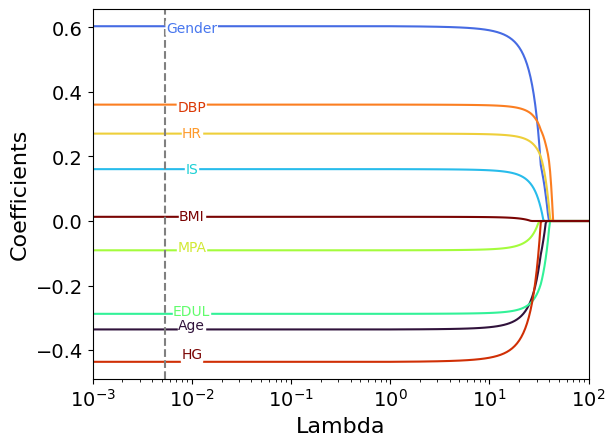

[-0.3261213   0.58560178  0.15559303 -0.28388016 -0.08629898  0.26796201
  0.35768876 -0.41812818  0.01157014]
0.01743374224450167


In [432]:
df = main_test[["Age","Gender","IS", "EDUL", "MPA", "SRMPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age","Gender","IS", "EDUL", "MPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age","Gender","IS", "EDUL", "MPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


# lasso with cross validated alpha
lassocv = LassoCV(alphas = alphas).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)

# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_
r_squared = lasso.score(X,Y)



cmap = cm.get_cmap('turbo')
plt.figure(figsize=(20,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

for i, column in enumerate(columns):
    y_pos = coefficients[i]
    color = cmap(i / 7.0)

    if i == 1:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(0, 0),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 5:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 3:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 6:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(0, -4),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    else:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white',edgecolor="white", pad=0))
        
        
plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axvline(x = best_alpha, color = 'gray', linestyle='dashed')
plt.axis('tight')
plt.xlabel('Lambda', fontsize = 16)
plt.xlim(0.001, 100)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, bbox_to_anchor=(1.01, 1.02), loc='upper left')
plt.legend().set_visible(False)
plt.show()




# Print the coefficients
print(coefficients)
print(r_squared)

Optimal alpha: 0.03274549162877728


<Figure size 2000x900 with 0 Axes>

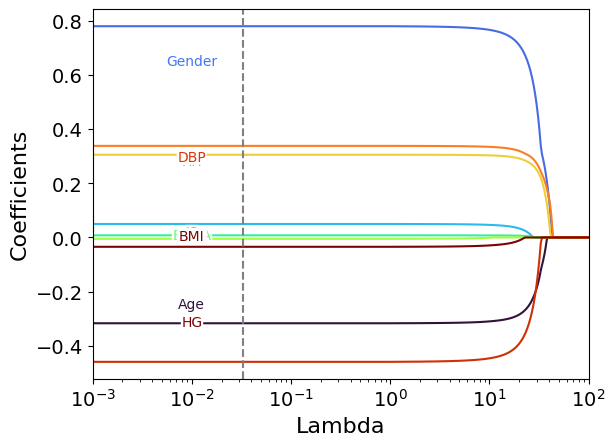

[-0.25174431  0.63641102  0.01581887  0.00439087  0.          0.27731354
  0.30261316 -0.31930773 -0.        ]
0.016634327112978298


In [433]:
df = main_test[["Age","Gender","IS", "EDUA", "MPA", "SRMPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age","Gender","IS", "EDUA", "MPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age","Gender","IS", "EDUA", "MPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


# lasso with cross validated alpha
lassocv = LassoCV(alphas = alphas).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)

# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_
r_squared = lasso.score(X,Y)



cmap = cm.get_cmap('turbo')
plt.figure(figsize=(20,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

for i, column in enumerate(columns):
    y_pos = coefficients[i]
    color = cmap(i / 7.0)

    if i == 1:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(0, 0),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 5:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 3:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white', edgecolor="white", pad=0))
    elif i == 6:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(0, -4),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    else:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='square', facecolor='white',edgecolor="white", pad=0))
        
        
plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axvline(x = best_alpha, color = 'gray', linestyle='dashed')
plt.axis('tight')
plt.xlabel('Lambda', fontsize = 16)
plt.xlim(0.001, 100)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, bbox_to_anchor=(1.01, 1.02), loc='upper left')
plt.legend().set_visible(False)
plt.show()




# Print the coefficients
print(coefficients)
print(r_squared)

## 11.2 Self-report PA

Optimal alpha: 0.003511191734215131


<Figure size 1200x900 with 0 Axes>

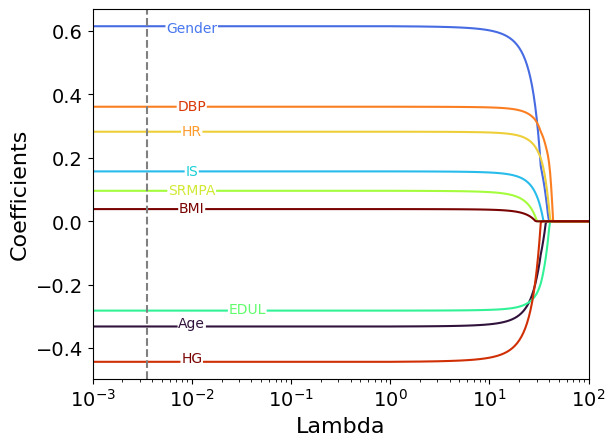

[-0.32590796  0.60428358  0.15454082 -0.2795276   0.09276633  0.28042118
  0.35942291 -0.43230391  0.03697564]
0.017491353080682948


In [434]:
df = main_test[["Age", "Gender", "IS", "EDUL", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Gender", "IS", "EDUL", "SRMPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "Gender", "IS", "EDUL", "SRMPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('turbo')
plt.figure(figsize=(12,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

# lasso with cross validated alpha
lassocv = LassoCV(alphas = alphas).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)


# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_
r_squared = lasso.score(X,Y)

for i, column in enumerate(columns):
    y_pos = coefficients[i]
    color = cmap(i / 7.0)
    
    if i == 3:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(40, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 7:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(0, -3),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    else:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white',edgecolor="white", pad=0))


plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Lambda', fontsize = 16)
plt.axvline(x = best_alpha, color = 'gray', linestyle='dashed')
plt.xlim(0.001, 100)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
#plt.legend(columns, bbox_to_anchor=(1.01, 1.02), loc='upper left')
plt.legend().set_visible(False)
plt.show()


# Print the coefficients
print(coefficients)
print(r_squared)